In [1]:
import numpy as np
import os
import time
import scipy
import pybullet as p
import pybullet_data
import matplotlib.pyplot as plt
import pickle
from mpl_toolkits.mplot3d import Axes3D

pybullet build time: Oct 14 2023 15:43:53


In [2]:
gmm_5 = pickle.load(open("gmm_models/gmm_5", "rb"))
gmm_6 = pickle.load(open("gmm_models/gmm_6", "rb"))

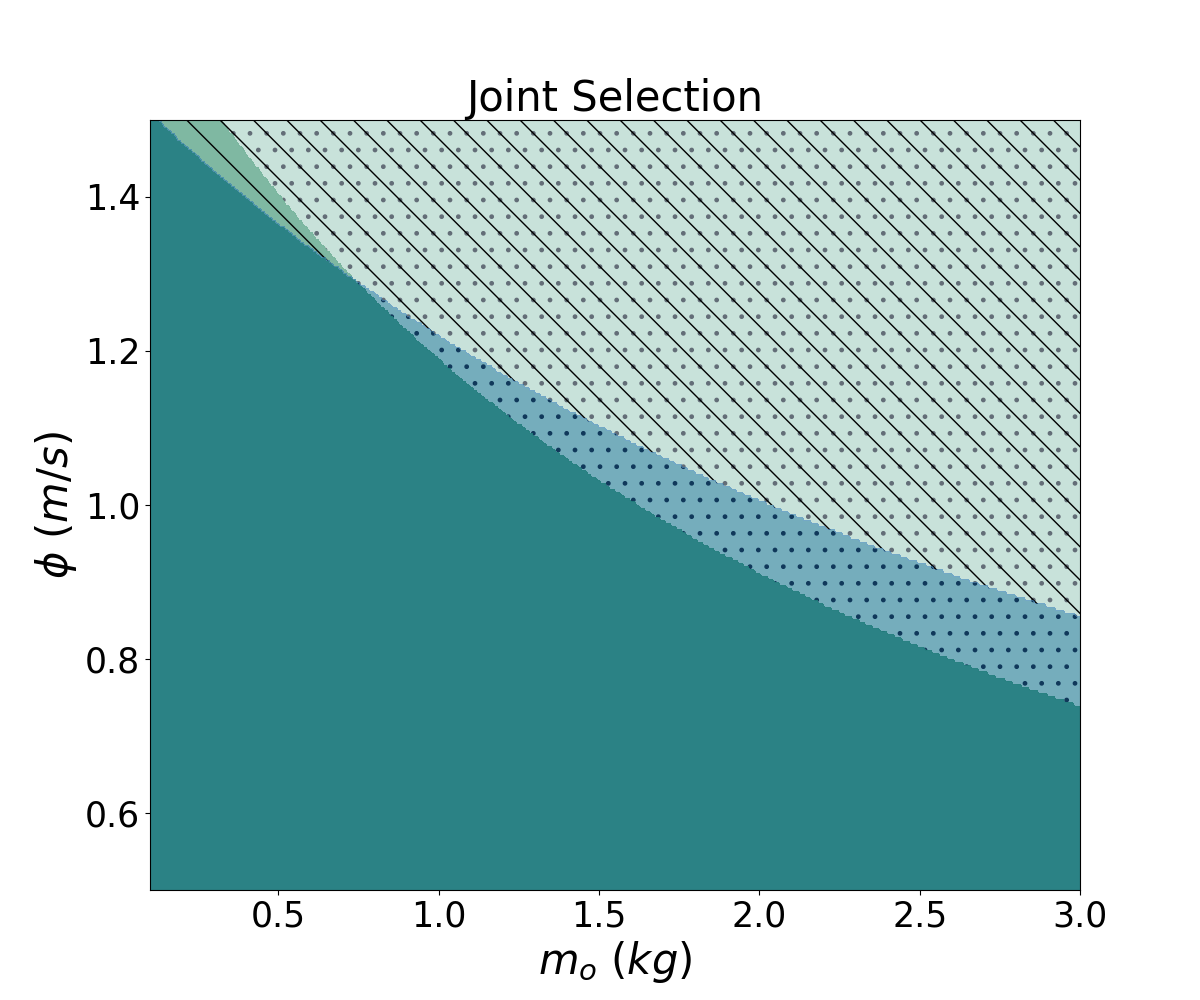

In [4]:
# At a given object position, we vary the mass of th object and desired hitting flux.

X_des = np.array([0.5, 0.4, 0.2])

pred_6 = gmm_6.predict(np.array([0,1,2]), X_des.reshape(-1,1).T)
pred_5 = gmm_5.predict(np.array([0,1,2]), X_des.reshape(-1,1).T)

m_range = np.linspace(0.1, 3, 500)
phi_range = np.linspace(0.5, 1.5, 250)

m_grid, phi_grid = np.meshgrid(m_range, phi_range)
m_sparse, phi_sparse = np.meshgrid(m_range, phi_range, sparse=True)

check_6 = pred_6[0][1] >= phi_grid * ( m_grid / pred_6[0][0] + 1 )
check_5 = pred_5[0][1] >= phi_grid * ( m_grid / pred_5[0][0] + 1 )


%matplotlib widget
fig = plt.figure(figsize=(12,10)) 
ax = fig.add_subplot()

cs1 = ax.contourf(m_grid, phi_grid, check_6,  hatches=['.', None],  cmap = 'Greens', alpha=0.9)
cs2 = ax.contourf(m_grid, phi_grid, check_5, hatches=['\\', None],  cmap='Blues', alpha=0.5)

ax.set_xlabel('$m_o$ $(kg)$', fontsize = 30)
ax.set_ylabel('$\phi$ $(m/s)$', fontsize = 30)
ax.set_title("Joint Selection", fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=25)

plt.show()
# plt.savefig("joint_selection", transparent=False, bbox_inches='tight', pad_inches = 0.25, dpi=200)

In [ ]:
# The other analysis will be done at a given 

pred_6 = gmm_6.predict(np.array([0,1,2]), X_des.reshape(-1,1).T)
pred_5 = gmm_5.predict(np.array([0,1,2]), X_des.reshape(-1,1).T)

m_range = np.linspace(0.1, 3, 500)
phi_range = np.linspace(0.5, 1.5, 250)

m_grid, phi_grid = np.meshgrid(m_range, phi_range)
m_sparse, phi_sparse = np.meshgrid(m_range, phi_range, sparse=True)

check_6 = pred_6[0][1] >= phi_grid * ( m_grid / pred_6[0][0] + 1 )
check_5 = pred_5[0][1] >= phi_grid * ( m_grid / pred_5[0][0] + 1 )


%matplotlib widget
fig = plt.figure(figsize=(12,10)) 
ax = fig.add_subplot()

cs1 = ax.contourf(m_grid, phi_grid, check_6,  hatches=['.', None],  cmap = 'Greens', alpha=0.9)
cs2 = ax.contourf(m_grid, phi_grid, check_5, hatches=['\\', None],  cmap='Blues', alpha=0.5)

ax.set_xlabel('$m_o$ $(kg)$', fontsize = 30)
ax.set_ylabel('$\phi$ $(m/s)$', fontsize = 30)
ax.set_title("Joint Selection", fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=25)

plt.show()
# plt.savefig("joint_selection", transparent=False, bbox_inches='tight', pad_inches = 0.25, dpi=200)